In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [9]:
df = pd.read_csv("../data/processed/with_patient_id.csv")

df = df.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)

df.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h,patient_id
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.27,10.66,13.55,0.2621,24,M,2,Elective,0,1
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.22,11.94,13.65,0.3353,24,M,2,Elective,0,1
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.25,10.24,13.69,0.1678,24,M,2,Elective,0,1
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.24,10.72,13.61,0.1961,24,M,2,Elective,0,1
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.21,11.46,13.49,0.3000,24,M,2,Elective,0,1


In [10]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (293248, 23)

Columns:
 ['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'gender', 'comorbidity_index', 'admission_type', 'deterioration_next_12h', 'patient_id']

Missing Values:
 hour_from_admission       0
heart_rate                0
respiratory_rate          0
spo2_pct                  0
temperature_c             0
systolic_bp               0
diastolic_bp              0
oxygen_device             0
oxygen_flow               0
mobility_score            0
nurse_alert               0
wbc_count                 0
lactate                   0
creatinine                0
crp_level                 0
hemoglobin                0
sepsis_risk_score         0
age                       0
gender                    0
comorbidity_index         0
admission_type            

In [11]:
TARGET = "deterioration_next_12h"

# Row-level
row_ratio = df[TARGET].value_counts(normalize=True)

# Patient-level
patient_labels = df.groupby("patient_id")[TARGET].max()
patient_ratio = patient_labels.value_counts(normalize=True)

print("Row-level distribution:\n", row_ratio)
print("\nPatient-level distribution:\n", patient_ratio)

Row-level distribution:
 deterioration_next_12h
0    0.94595
1    0.05405
Name: proportion, dtype: float64

Patient-level distribution:
 deterioration_next_12h
0    0.805571
1    0.194429
Name: proportion, dtype: float64


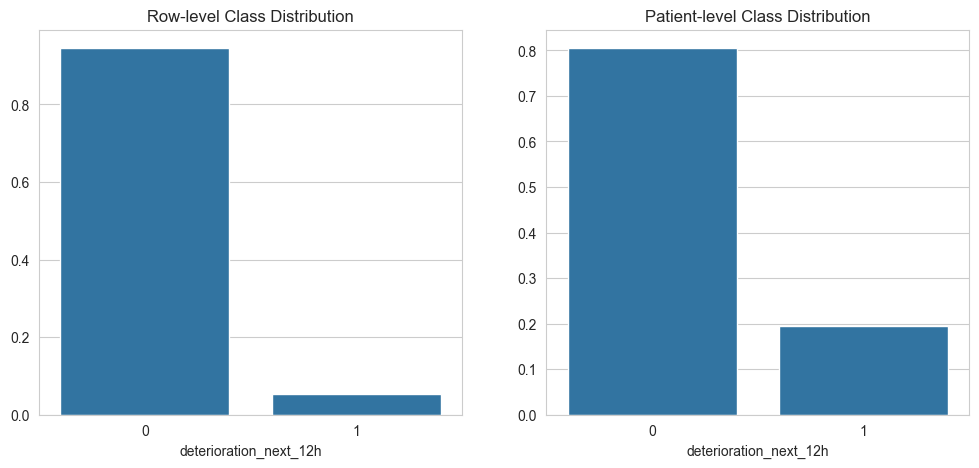

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=row_ratio.index, y=row_ratio.values, ax=axes[0])
axes[0].set_title("Row-level Class Distribution")

sns.barplot(x=patient_ratio.index, y=patient_ratio.values, ax=axes[1])
axes[1].set_title("Patient-level Class Distribution")

plt.show()

In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print("Missing columns:\n", missing)

Missing columns:
 Series([], dtype: int64)


In [14]:
if len(missing) > 0:
    missing.sort_values().plot(kind="barh")
    plt.title("Missing Data Distribution")
    plt.show()
else:
    print("No missing values in dataset.")

No missing values in dataset.


In [15]:
# Select patients
deteriorated_patients = df.groupby("patient_id")[TARGET].max()
deteriorated_ids = deteriorated_patients[deteriorated_patients == 1].index[:3]
stable_ids = deteriorated_patients[deteriorated_patients == 0].index[:3]

selected_ids = list(deteriorated_ids) + list(stable_ids)

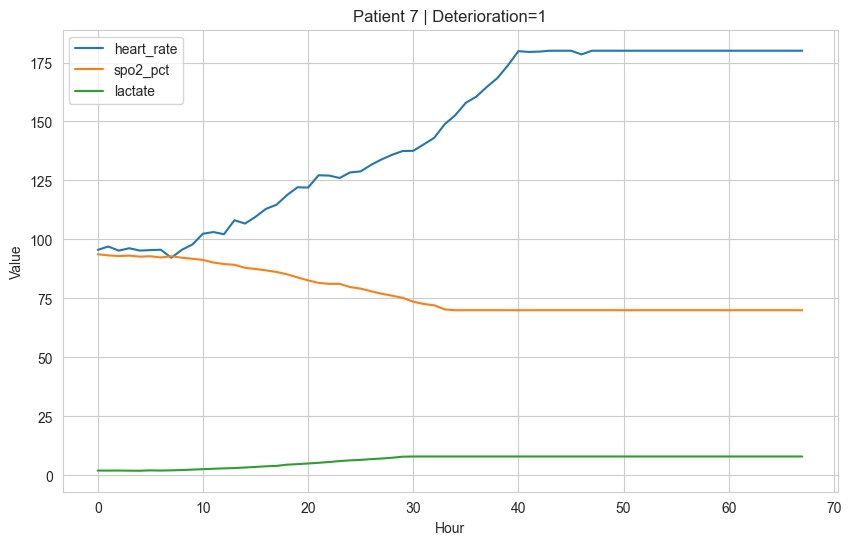

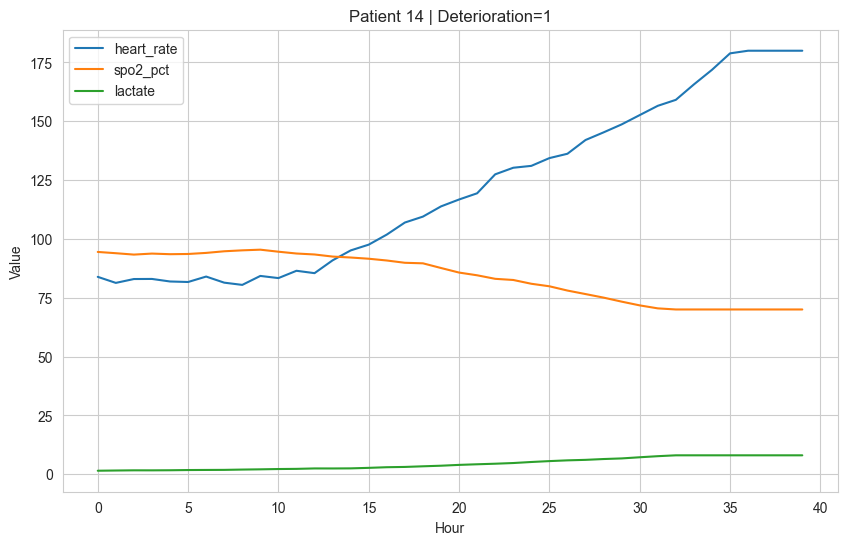

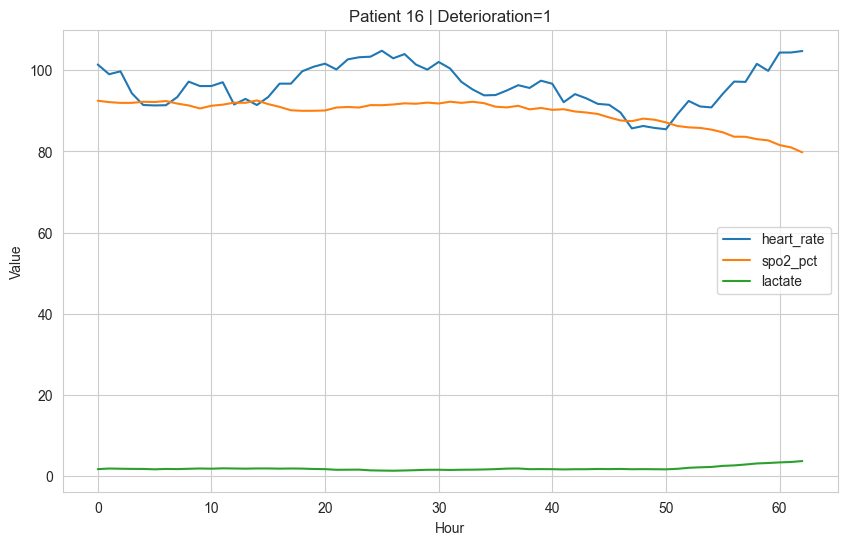

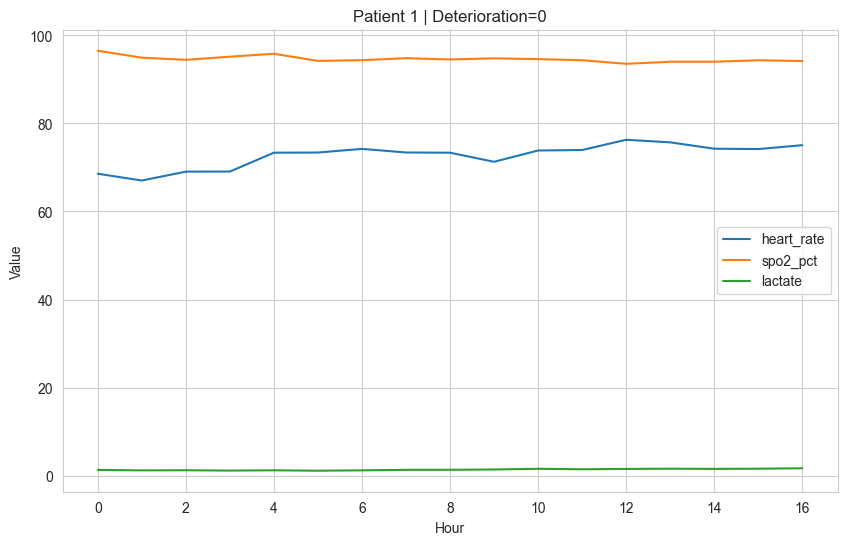

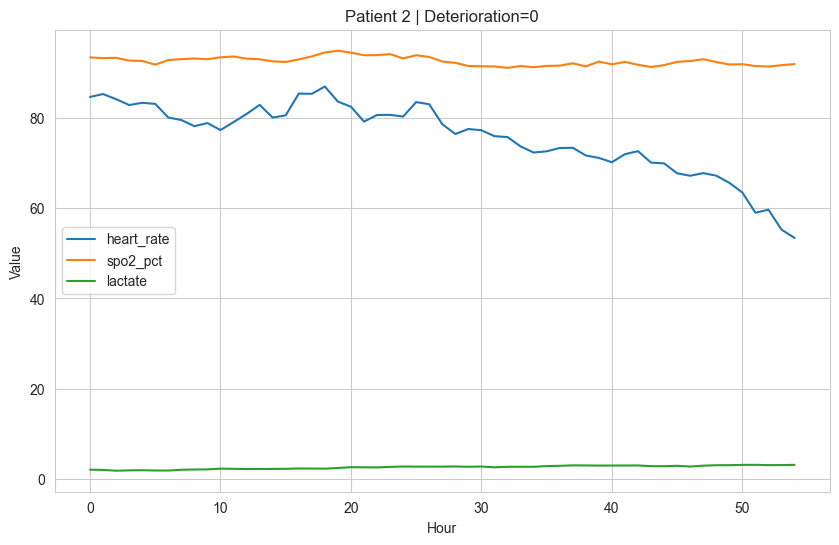

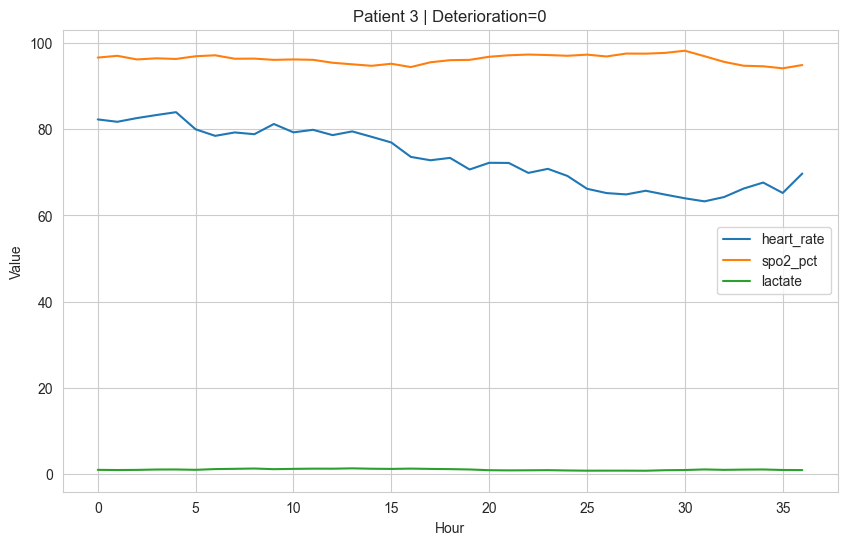

In [16]:
features_to_plot = ["heart_rate", "spo2_pct", "lactate"]

for pid in selected_ids:
    temp = df[df["patient_id"] == pid]

    plt.figure()
    for col in features_to_plot:
        plt.plot(temp["hour_from_admission"], temp[col], label=col)

    plt.title(f"Patient {pid} | Deterioration={temp[TARGET].max()}")
    plt.xlabel("Hour")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

In [17]:
timeline_data = []

for pid, group in df.groupby("patient_id"):
    if group[TARGET].max() == 1:
        event_idx = group[group[TARGET] == 1].index[0]
        event_time = group.loc[event_idx, "hour_from_admission"]

        pre_event = group[group["hour_from_admission"] < event_time]

        if len(pre_event) >= 6:
            timeline_data.append(pre_event.tail(6))

timeline_df = pd.concat(timeline_data)

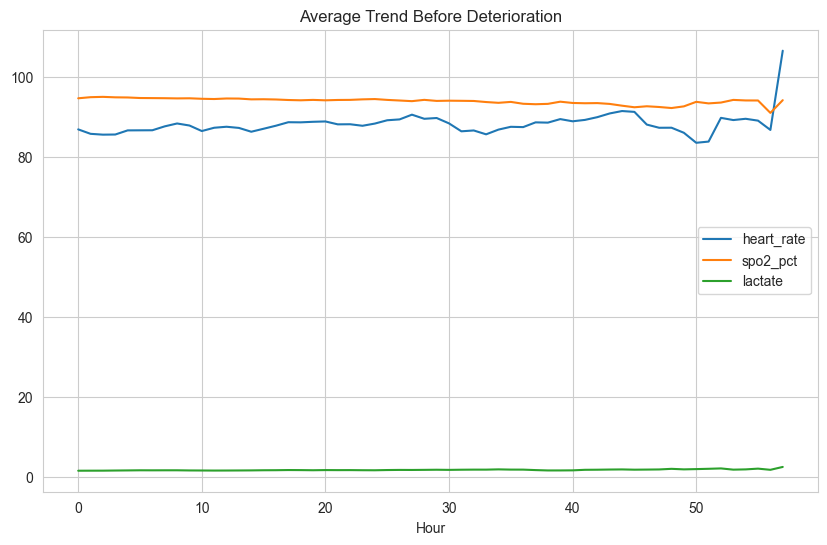

In [18]:
for col in ["heart_rate", "spo2_pct", "lactate"]:
    trend = timeline_df.groupby("hour_from_admission")[col].mean()

    plt.plot(trend.index, trend.values, label=col)

plt.title("Average Trend Before Deterioration")
plt.xlabel("Hour")
plt.legend()
plt.show()

In [19]:
df["hr_std"] = (
    df.groupby("patient_id")["heart_rate"]
    .rolling(6).std().reset_index(level=0, drop=True)
)

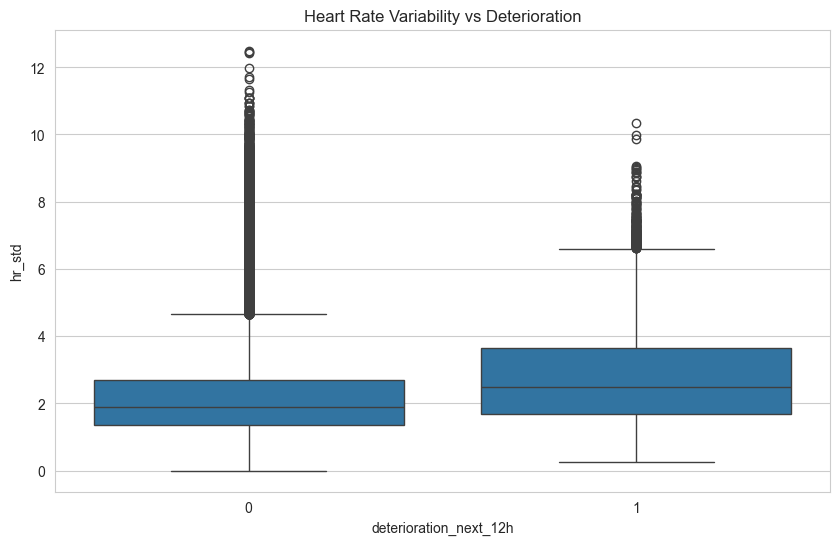

In [20]:
sns.boxplot(x=TARGET, y="hr_std", data=df)
plt.title("Heart Rate Variability vs Deterioration")
plt.show()

In [21]:
before_event = df[df["hour_from_admission"] < 12]
after_event = df[df["hour_from_admission"] >= 12]

corr_before = before_event.corr(numeric_only=True)
corr_after = after_event.corr(numeric_only=True)

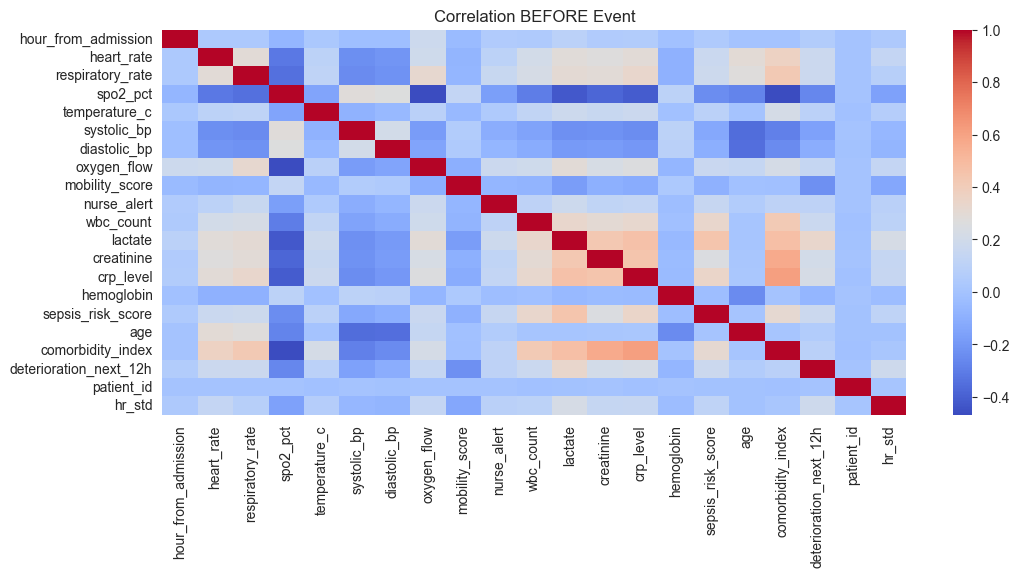

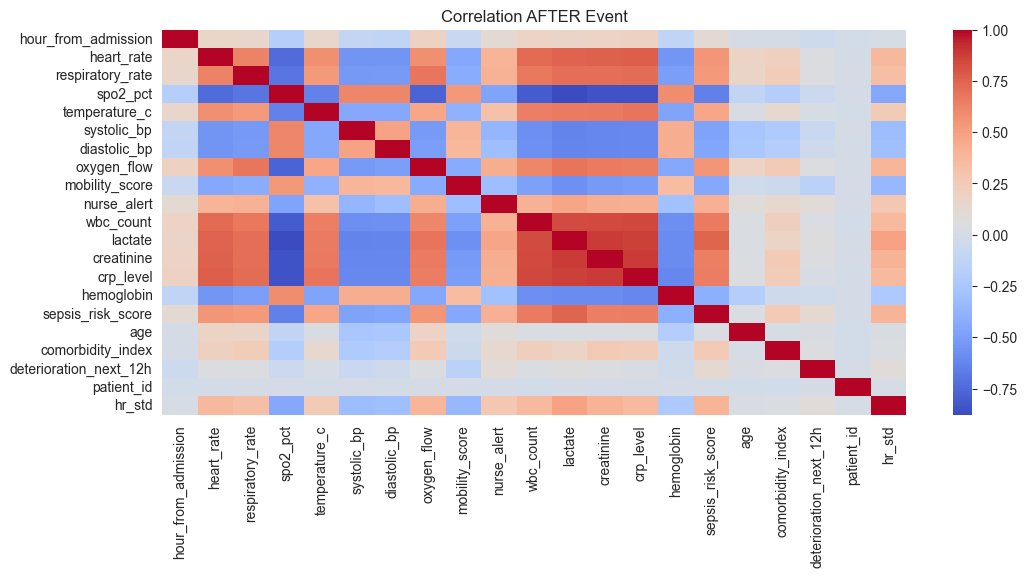

In [22]:
plt.figure(figsize=(12, 5))
sns.heatmap(corr_before, cmap="coolwarm")
plt.title("Correlation BEFORE Event")
plt.show()

plt.figure(figsize=(12, 5))
sns.heatmap(corr_after, cmap="coolwarm")
plt.title("Correlation AFTER Event")
plt.show()

In [24]:
def detect_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()

outliers = {}

for col in ["heart_rate", "spo2_pct", "lactate"]:
    outliers[col] = detect_outliers(df[col])

print("Outliers:", outliers)

Outliers: {'heart_rate': 16074, 'spo2_pct': 22219, 'lactate': 26963}


In [25]:
def compute_news2(row):
    score = 0

    rr = row["respiratory_rate"]
    if rr <= 8 or rr >= 25: score += 3
    elif 21 <= rr <= 24: score += 2
    elif 9 <= rr <= 11: score += 1

    spo2 = row["spo2_pct"]
    if spo2 <= 91: score += 3
    elif spo2 <= 93: score += 2
    elif spo2 <= 95: score += 1

    temp = row["temperature_c"]
    if temp <= 35: score += 3
    elif temp >= 39.1: score += 2
    elif temp <= 36: score += 1

    sbp = row["systolic_bp"]
    if sbp <= 90: score += 3
    elif sbp <= 100: score += 2
    elif sbp <= 110: score += 1

    hr = row["heart_rate"]
    if hr <= 40 or hr >= 131: score += 3
    elif hr >= 111: score += 2
    elif hr >= 91: score += 1

    return score

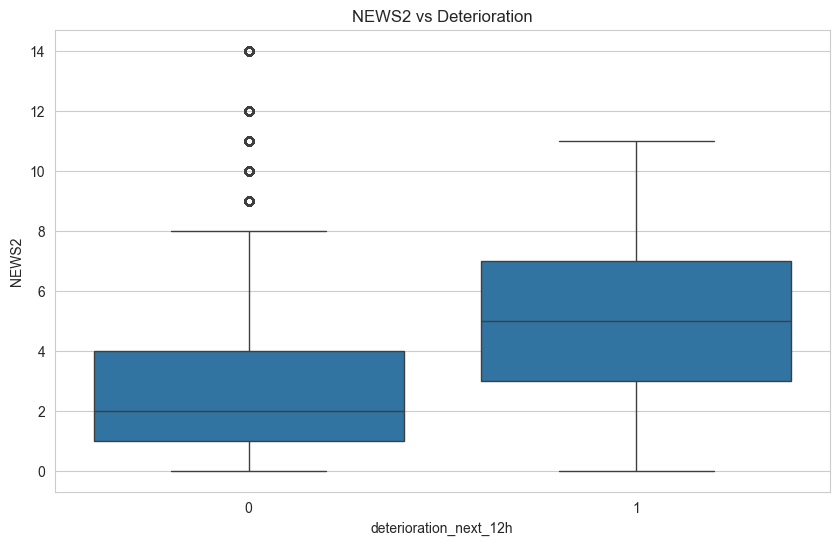

In [26]:
df["NEWS2"] = df.apply(compute_news2, axis=1)

sns.boxplot(x=TARGET, y="NEWS2", data=df)
plt.title("NEWS2 vs Deterioration")
plt.show()

In [27]:
df.to_csv("../data/processed/eda_enriched.csv", index=False)